In [1]:
# Install pandas into the current Python environment (run this cell once), then import it
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
import pandas as pd
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "datasets"])
import matplotlib.pyplot as plt
from datasets import load_dataset
import sys, subprocess
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
from ast import literal_eval
df['job_skills']= df['job_skills'].apply(lambda x: literal_eval(x) if pd.notna(x) else x)


c:\Users\Admin\anaconda3\envs\python_data\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
target_type = ['Full-time','Contractor']

In [15]:
df_filtered = df[df['job_title_short'].isin(target_job_titles)]
df_filtered = df_filtered[df_filtered['job_country'] == 'United States']
df_filtered = df_filtered[df_filtered['job_schedule_type'].isin(target_type)]
df_filtered = df_filtered[df_filtered['salary_year_avg'].notna()]


In [16]:
df_filtered['job_title_type'] = df_filtered['job_title_short'] + ',' + df_filtered['job_schedule_type']

In [24]:
job_stats = df_filtered.groupby('job_title_type').agg(
    job_count = ('job_title_short','count'),
    mean_salary = ('salary_year_avg','mean')
)

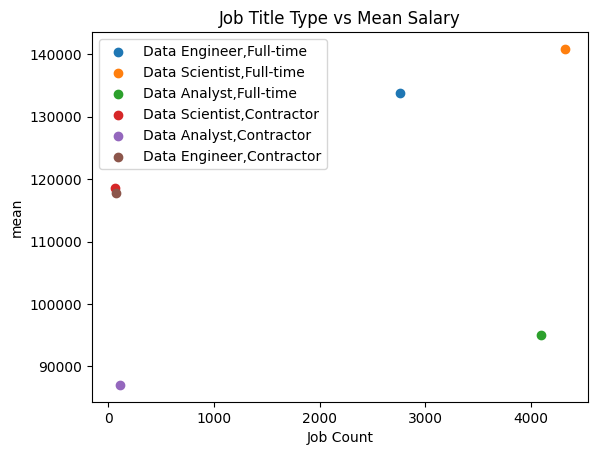

In [31]:
unique_types = df_filtered['job_title_type'].unique()
for job_type in unique_types:
    row = job_stats.loc[job_type]
    plt.scatter(row['job_count'], row['mean_salary'], label=job_type)
    plt.legend()
    plt.xlabel('Job Count')
    plt.ylabel('mean')
    plt.title('Job Title Type vs Mean Salary')
